In [1]:
import torch
import numpy as np
import h5py
import train
import matplotlib.pyplot as plt
from mri_utils import batched_mri_encoding, batched_mri_decoding, check_adjoint, make_acc_mask
from functools import partial

/home/ee2178/scratch/ee2178/miniconda3/envs/env/lib/python3.9/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/scratch/ee2178/miniconda3/envs/env/lib/python3.9/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [3]:
# Load smaps
# fname = "file1000323.h5"
# smaps_fname = "../../datasets/fastmri_preprocessed/knee_coil_combined/pd/val/" + fname
# kspace_fname = '../../datasets/fastmri/knee/multicoil_val/' + fname

fname = "file_brain_AXT2_200_2000572.h5"
kspace_fname = "../../datasets/fastmri/brain/multicoil_val/"+fname
slice_ = 7
smaps_fname = "../../datasets/fastmri_preprocessed/brain_T2W_coil_combined/val/"+fname
# slice = 17
with h5py.File(smaps_fname) as f:
    smaps = f['smaps'][()]
    x = f['image'][()]

with h5py.File(kspace_fname) as f:
    kspace = f['kspace'][()]
    volume_kspace = f['kspace'][()]

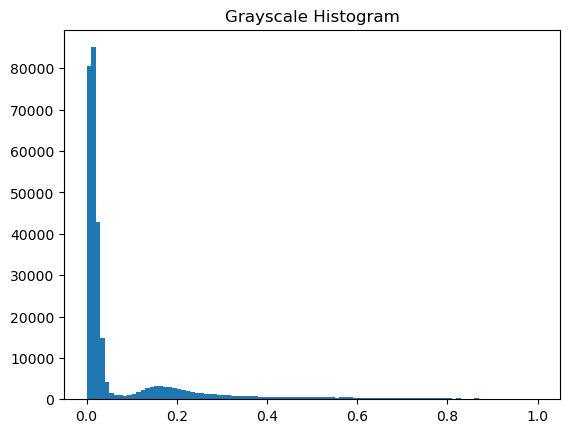

In [21]:
x_slice_abs = np.abs(x[slice_])*2e3

# Make a histogram:
plt.hist(x_slice_abs[x_slice_abs > 0], 100, [0, 1])
plt.title('Grayscale Histogram')
plt.show()

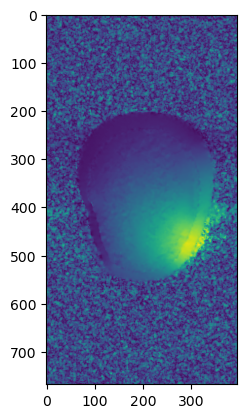

In [26]:
plt.imshow(np.abs(smaps[slice_, 0]))

In [3]:
# Send all to GPU
kspace = torch.from_numpy(kspace).to('cuda')
smaps = torch.from_numpy(smaps).to('cuda')
# Make a mask
mask = make_acc_mask(shape = (smaps.shape[-2], smaps.shape[-1]), accel = 6, acs_lines = 24)
mask = mask.to('cuda')

E = partial(batched_mri_encoding, mask = mask, smaps = smaps)
EH = partial(batched_mri_decoding, mask = mask, smaps = smaps)

# Check adjoint
check_adjoint(E, EH, smaps[0].conj())

(tensor(0.0002+0.0006j, device='cuda:0'),
 tensor(-209.0398+918.7362j, device='cuda:0'),
 tensor(-209.0400+918.7356j, device='cuda:0'))

In [7]:
# Load denoiser and check if our denoiser works
def load_model(config, verbose = False, device = 'cpu'):
    # Load Denoiser
    model_args_file = open(config)
    model_args = json.load(model_args_file)
    model_args_file.close()
    if verbose == True:
        pprint(model_args)
    net, _, _, _ = train.init_model(model_args, device=device)
    return net
net = load_model("trained_nets/knee/LPDS_ImMAP2p5_SSDU_R6_baseAccel1x_sigmaScaleON_noiseLOG/args.json", device = 'cuda')

Initializing net from trained_nets/knee/LPDS_ImMAP2p5_SSDU_R6_baseAccel1x_sigmaScaleON_noiseLOG/net.ckpt ...
Loading net state-dict...
Loading opt state-dict...
Loading sched state-dict...
Total Number of Parameters: 760,710
Using trained_nets/knee/LPDS_ImMAP2p5_SSDU_R6_baseAccel1x_sigmaScaleON_noiseLOG ...


In [4]:
# Send x to torch and GPU
x = torch.from_numpy(x).to('cuda')

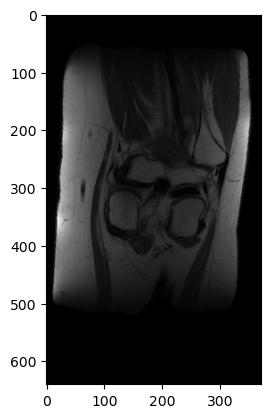

In [6]:
slice_ = 25
plt.imshow(x[slice_].abs().detach().cpu().numpy(), cmap = 'gray')

In [9]:
noisy_x_slice = noisy_x_slice.view(1, 1, noisy_x_slice.shape[-2], noisy_x_slice.shape[-1])

out = net(noisy_x_slice, noise_level)[0][0,0]
plt.imshow(out.abs().detach().cpu().numpy(), cmap = 'gray')

NameError: name 'net' is not defined

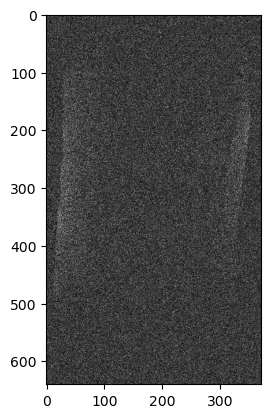

In [15]:
##### Try adding some noise
from train_utils import awgn
scale_fac = 5e3
noise_level = 1.5
noisy_x_slice, sigma_n = awgn(x[slice_]*scale_fac, noise_level)
plt.imshow(noisy_x_slice.abs().detach().cpu().numpy(), cmap = 'gray')

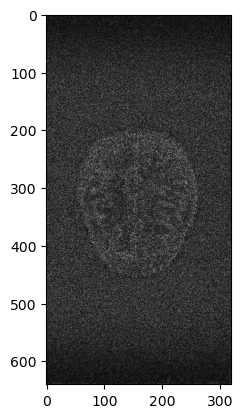

In [43]:
res = out - x[slice_]*scale_fac

plt.imshow(res.abs().detach().cpu().numpy()*5, cmap = 'gray')

In [27]:
import math
test = torch.randn(10000, 1, 1, 1)
def awgn(input, noise_std, dist = 'uniform'):
    """ Additive White Gaussian Noise
    y: clean input image
    noise_std: (tuple) noise_std of batch size N is uniformly sampled 
                between noise_std[0] and noise_std[1]. Expected to be in interval
                [0,1]
    """

    if not isinstance(noise_std, (list, tuple)):
        sigma = noise_std
    elif isinstance(noise_std, (list, tuple)) and dist == 'uniform': # uniform sampling of sigma
        sigma = noise_std[0] + \
               (noise_std[1] - noise_std[0])*torch.rand(len(input),1,1,1, device=input.device)
    elif isinstance(noise_std, (list, tuple)) and dist == 'log':
        # log uniform has support [a, b], corresponding to uniform w/ support [exp(a), exp(b)].
        # We can usually assume a = 0, b = 1 for diffusion training
        # So, draw a uniform sample from [exp(a), exp(b)], then take its log
        # Insert tiny epsilon so to not run into numerical stability issues
        eps = 1e-4
        sigma = 10**(math.log10(noise_std[0]+eps) + \
            (math.log10(noise_std[1]) - math.log10(noise_std[0]+eps))*torch.rand(len(input),1,1,1, device=input.device))
    elif isinstance(noise_std, (list, tuple)) and dist == 'cosine':
        # Y = arcsin(X), X ~ U([0, 1])
        # Ignore noise type all together, hard code for now
        # Draw uniform number [0, 1]
        x = torch.rand(len(input),1,1,1, device=input.device)

        # Take arccos
        y = torch.asin(x)

        # Scale to [0, 1]
        sigma = (y)/(math.pi/2)
    return input + torch.randn_like(input) * (sigma), sigma
        
_, sigma_vec = awgn(test, [0.1,0.5], "log")



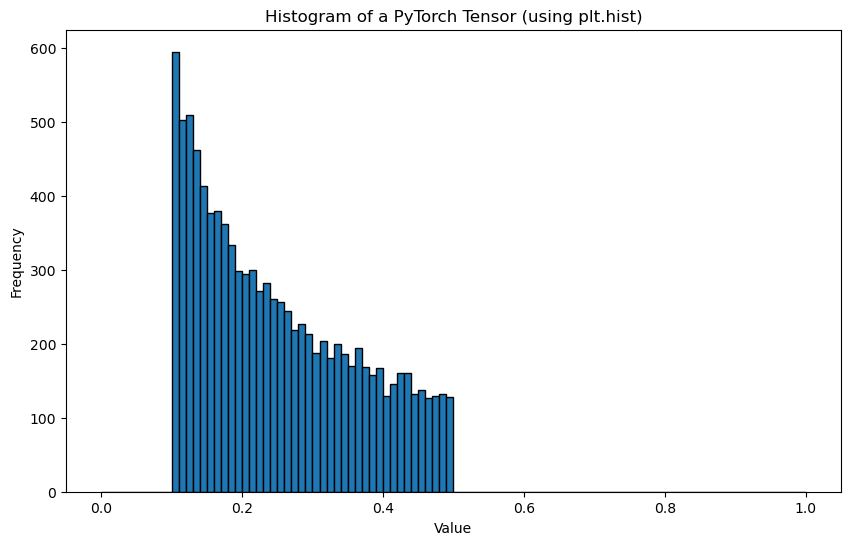

In [28]:
plt.figure(figsize=(10, 6))
# Convert tensor to NumPy array using .numpy()
plt.hist(sigma_vec[:, 0, 0, 0].numpy(), bins=100, range=(0, 1), edgecolor='black')
plt.title("Histogram of a PyTorch Tensor (using plt.hist)")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

In [14]:
import torch.nn.functional as F
def gaussian_blur_complex(img, pixel_width):
    """
    img: complex tensor (B, C, H, W)
    pixel_width: odd integer kernel size

    sigma = pixel_width / 5
    """

    assert img.is_complex(), "Input must be a complex tensor"
    assert pixel_width % 2 == 1, "pixel_width must be odd"

    B, C, H, W = img.shape
    sigma = pixel_width / 5.0

    # --- Build Gaussian kernel ---
    coords = torch.arange(pixel_width, device=img.device, dtype=img.real.dtype)
    coords = coords - pixel_width // 2

    g = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
    g = g / g.sum()

    kernel_2d = torch.outer(g, g)
    kernel_2d = kernel_2d / kernel_2d.sum()

    # Shape for depthwise conv
    kernel = kernel_2d.view(1, 1, pixel_width, pixel_width)
    kernel = kernel.expand(C, 1, pixel_width, pixel_width)

    # --- Convolve real & imaginary parts ---
    padding = pixel_width // 2

    real_out = F.conv2d(img.real, kernel, padding=padding, groups=C)
    imag_out = F.conv2d(img.imag, kernel, padding=padding, groups=C)

    return torch.complex(real_out, imag_out)

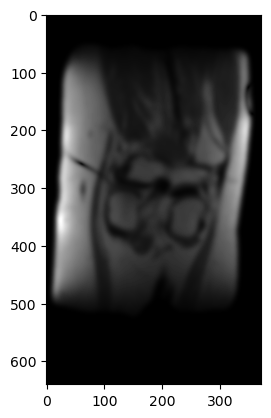

In [24]:
x_slice = x[slice_] * scale_fac
pixel_width = 21
x_slice_blur = gaussian_blur_complex(x_slice[None, None], pixel_width)
plt.imshow(x_slice_blur.abs().detach().cpu().numpy()[0,0], cmap = 'gray')

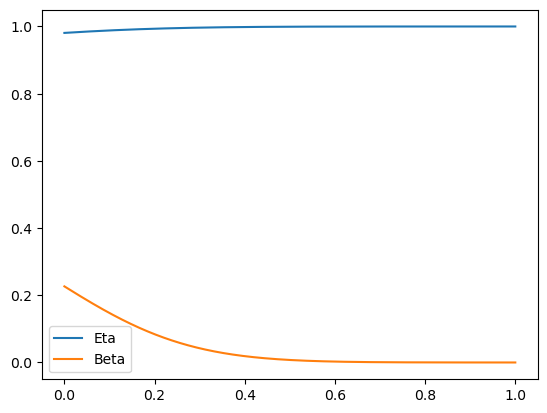

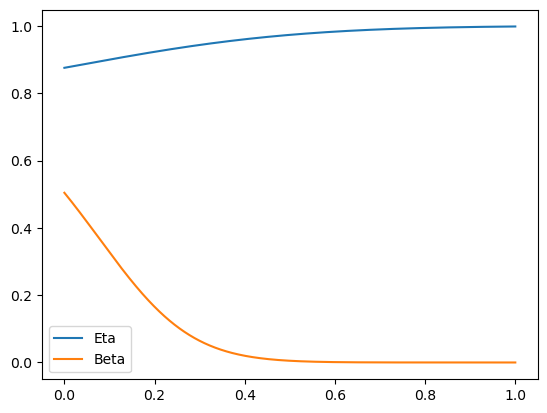

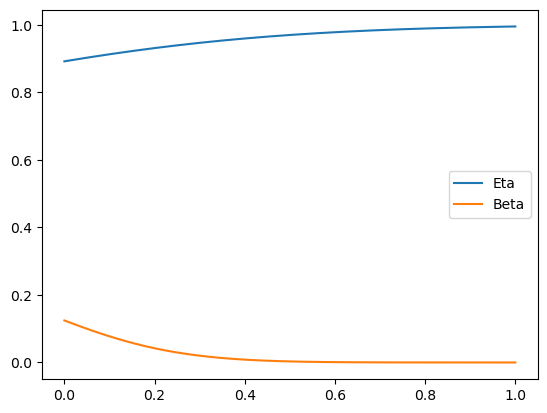

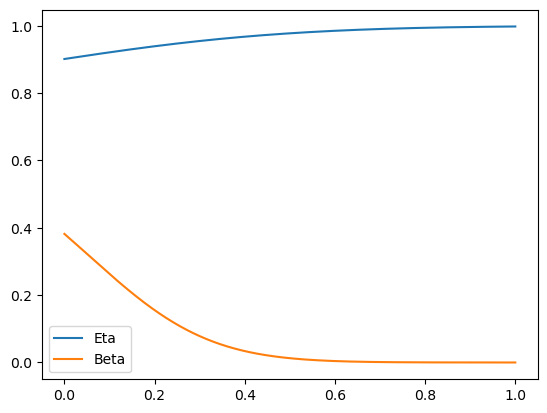

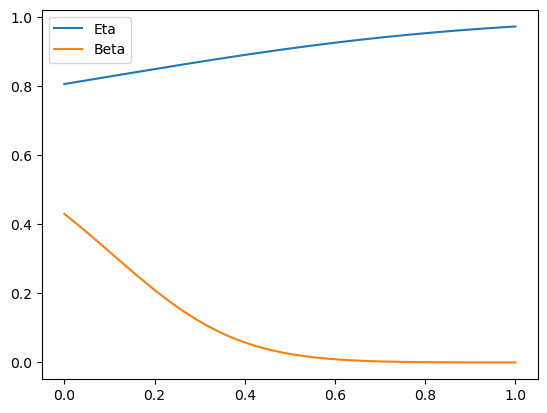

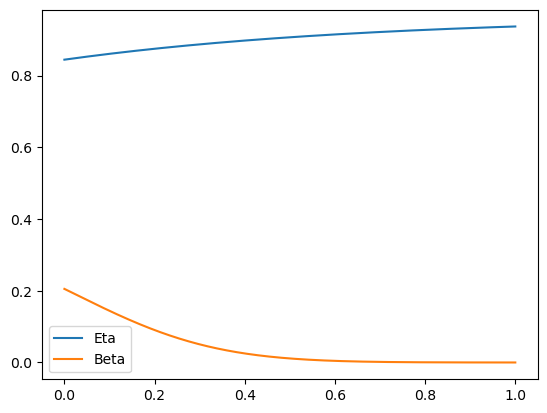

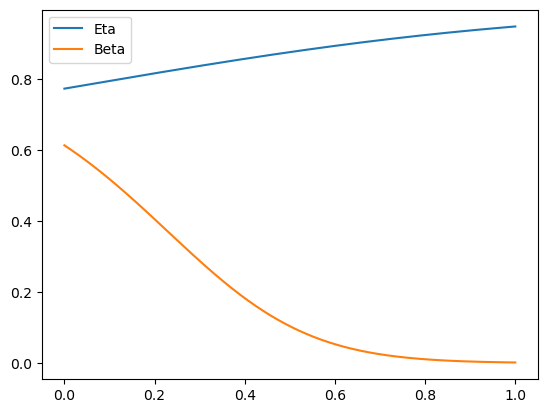

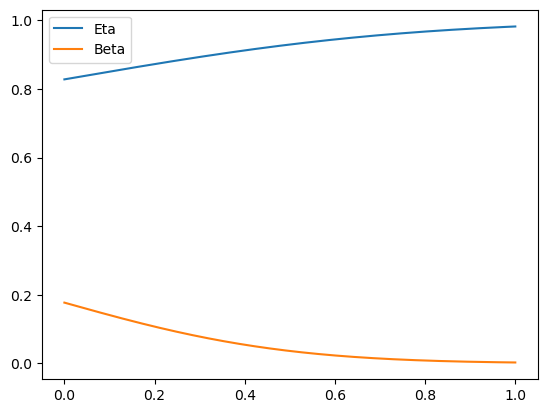

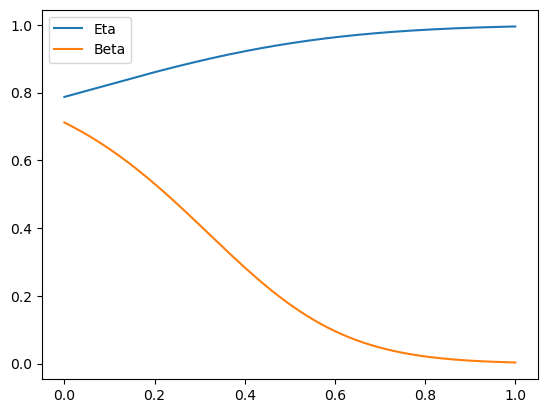

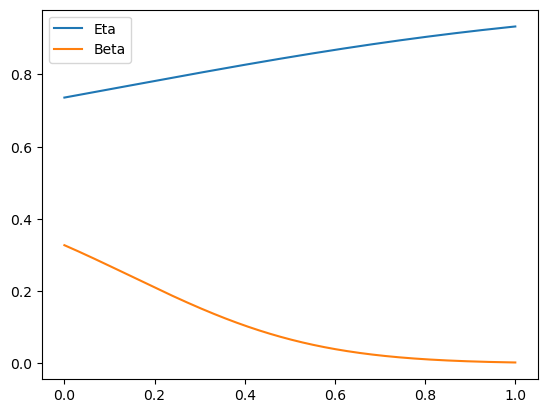

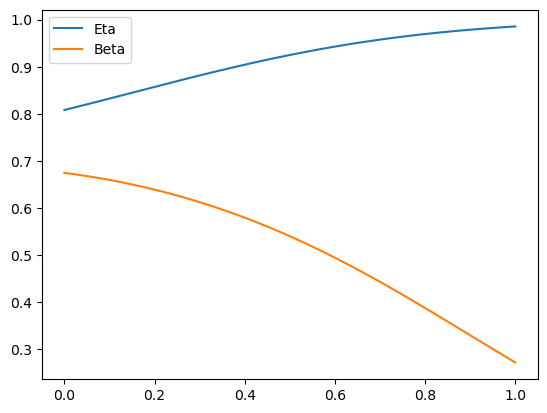

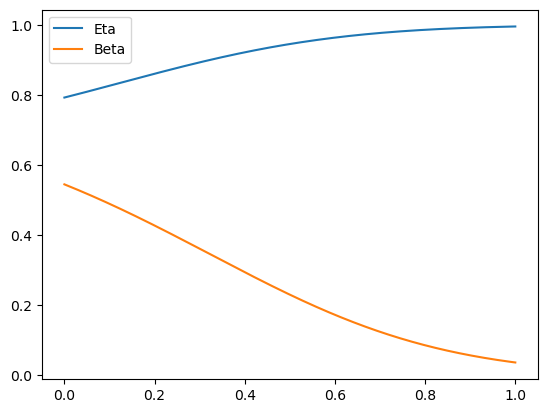

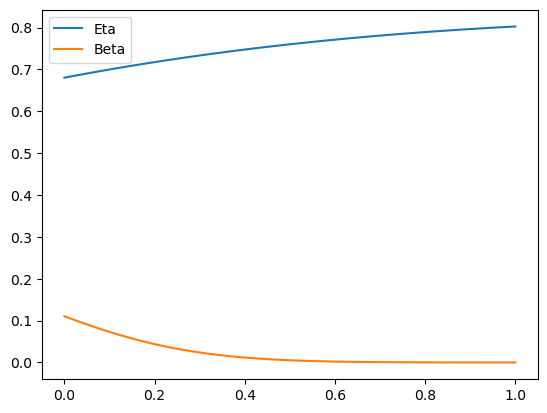

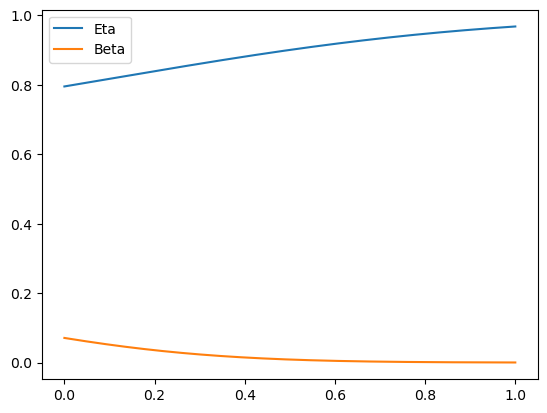

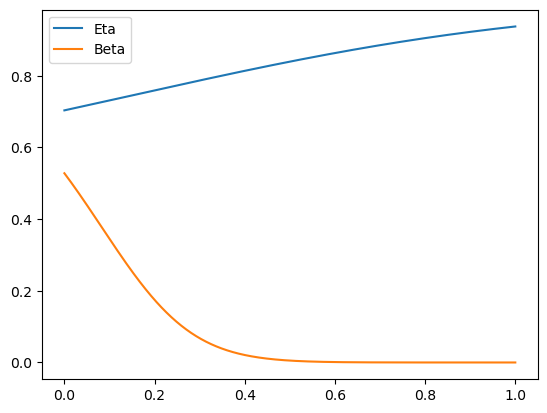

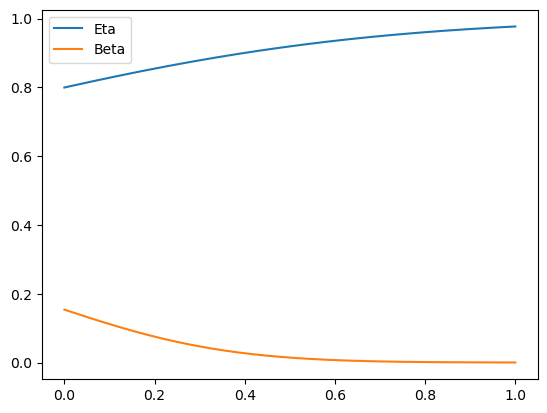

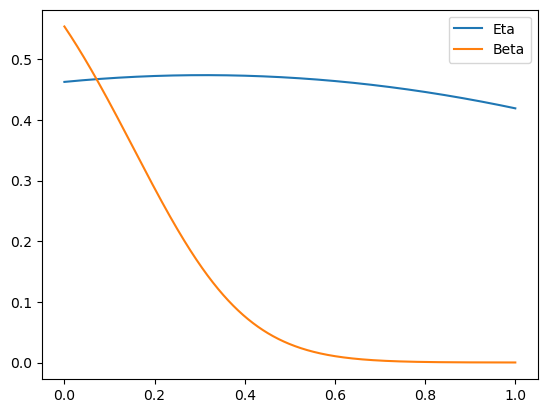

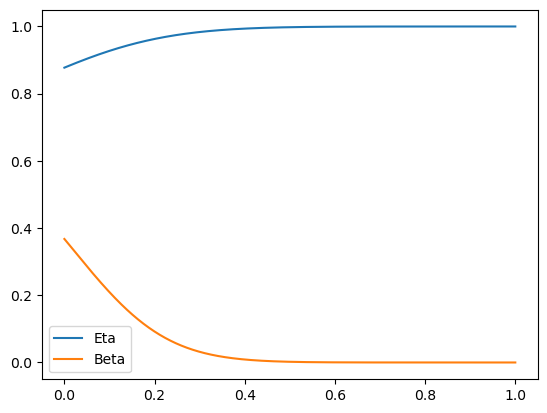

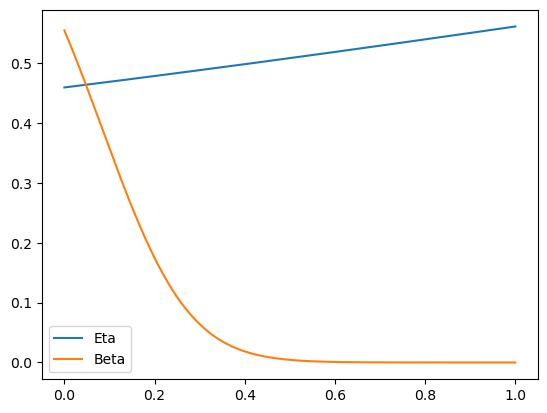

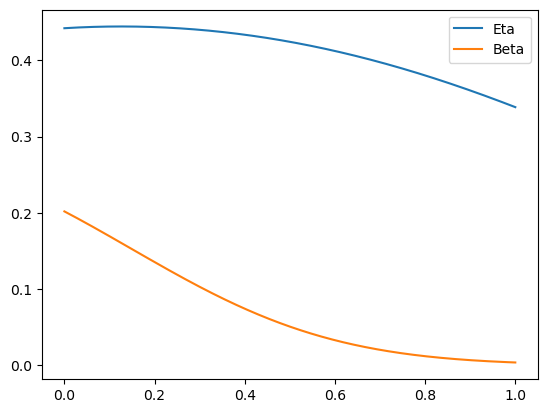

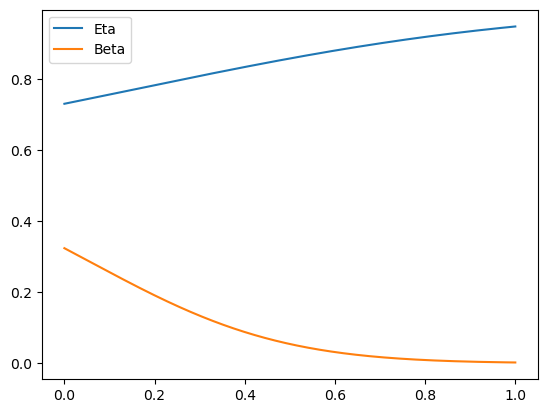

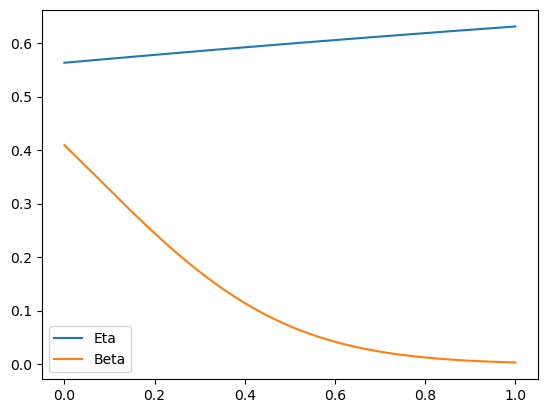

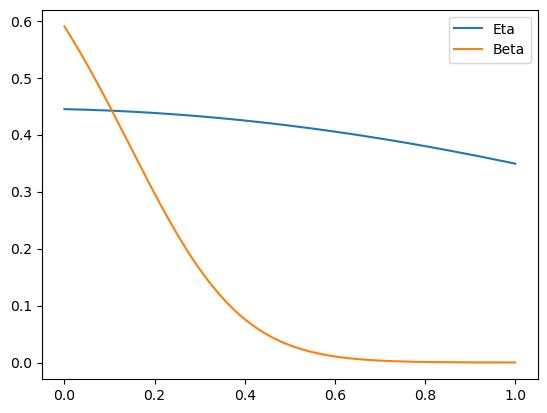

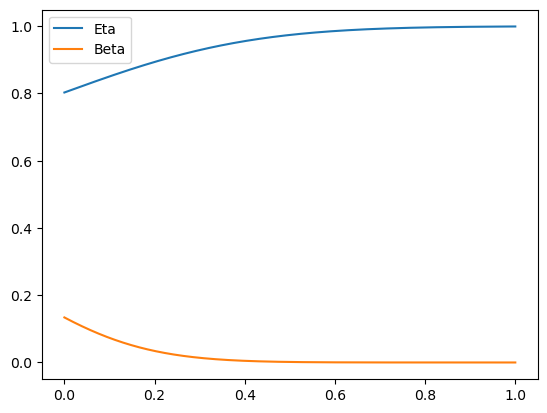

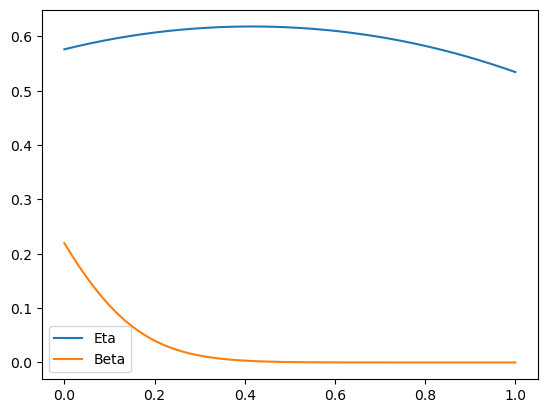

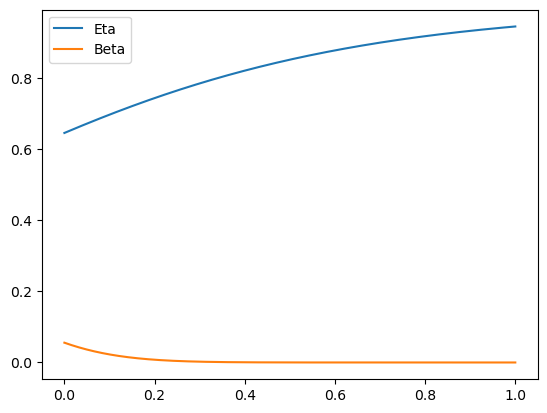

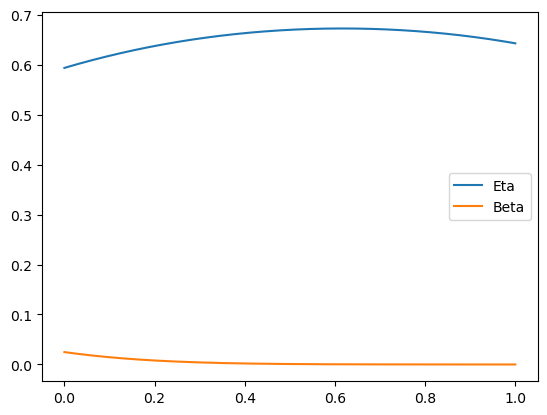

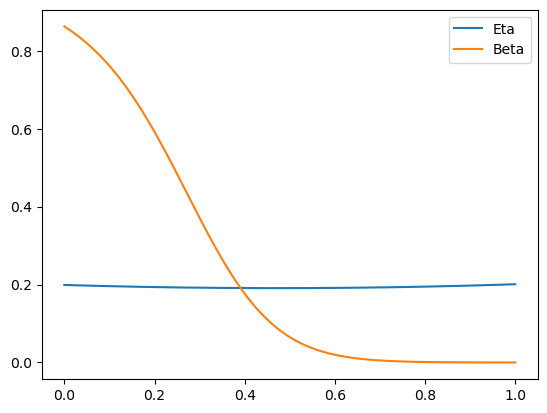

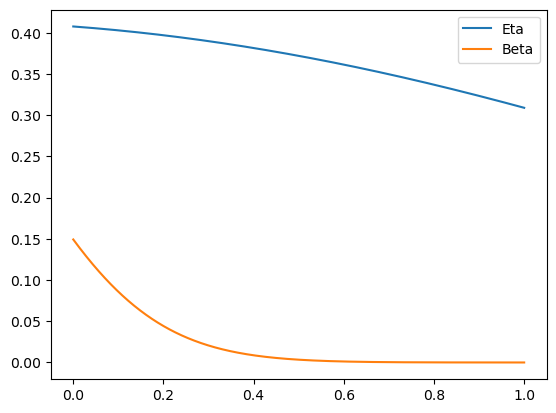

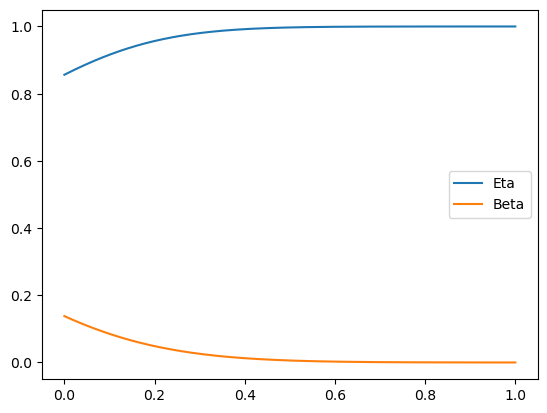

In [8]:
x = torch.linspace(0, 1, 1000, device = 'cuda')
for i in range(len(net.eta)):
    coeffs = net.eta[i].coeffs
    # Plot polynomials over [0, 1]
    y = torch.sigmoid(net.eta[i](x))
    z = torch.sigmoid(net.beta[i](x))
    plt.plot(x.detach().cpu().numpy(), y.detach().cpu().numpy())
    plt.plot(x.detach().cpu().numpy(), z.detach().cpu().numpy())
    plt.legend(["Eta", "Beta"])
    plt.show()

In [22]:
noise = torch.randn_like(x[0]).cpu().numpy()
import matplotlib.pyplot as plt
noise.shape
# plt.hist2d(noise.real, noise.imag, bins=20, cmap='plasma')

(640, 372)